# Ejercicio 6 
A continuacion elaboraremos casos de Benchmarking para el calculo de pesos segun cada algoritmo de los tres brindados.

## Algoritmo 1: Fully Connected Lineal con Cholesky en rango completo

In [8]:
# Imports necesarios
import numpy as np
import matplotlib.pyplot as plt
from alc import * # ! Checkear que este bien el import
path_base = "./cats_and_dogs"
X_t, Y_t, X_v, Y_v = cargarDataset(path_base) # Siendo _t nuestros modelos de training (entrenamiento) y _v de validation (validacion)

In [9]:
# Testeo matriz Y_v

cantGatos = 0
for i in range(Y_v.shape[1]):
    if Y_v[1,i] == 1:
        cantGatos += 1
        
print(f"Cantidad de gatos en Y_v: {cantGatos}")
cantGatos = 0
for i in range(Y_t.shape[1]):
    if Y_t[1,i] == 1:
        cantGatos += 1
        
print(f"Cantidad de gatos en Y_t: {cantGatos}")

Cantidad de gatos en Y_v: 500
Cantidad de gatos en Y_t: 1000


In [ ]:
# Dado cada modelo pedimos una matriz W
W_Cholesky = fullyConnectedLineal_Cholesky(X_t, Y_t)
W_QR = fullyConnectedLineal_QR(X_t, Y_t)
W_SVD = fullyConnectedLineal_SVD(X_t, Y_t)

Y_Cholesky = productoMatricial(W_Cholesky, X_v)
Y_QR = productoMatricial(W_QR, X_v)
Y_SVD = productoMatricial(W_SVD, X_v)

matrizConfusion_Cholesky = np.zeros((2,2)) # Fila 0: Gato, Fila 1: Perro | Columna 0: Gato, Columna 1: Perro
matrizConfusion_QR = np.zeros((2,2)) # Fila 0: Gato, Fila 1: Perro | Columna 0: Gato, Columna 1: Perro
matrizConfusion_SVD = np.zeros((2,2)) # Fila 0: Gato, Fila 1: Perro | Columna 0: Gato, Columna 1: Perro

def actualizarMatrizDeConfusion(matrizConfusion, esPerro, esPerro_Predicho):
    if esPerro and esPerro_Predicho:
        matrizConfusion[1][1] += 1
    elif esPerro and not esPerro_Predicho:
        matrizConfusion[0][1] += 1
    elif not esPerro and esPerro_Predicho:     
        matrizConfusion[1][0] += 1
    else:     
        matrizConfusion[0][0] += 1

row_Y, col_Y  = Y_Cholesky.shape
printY_v = ""
printY_Cholesky = ""
printY_QR = ""
printY_SVD = ""
for i in range(col_Y):
    esPerro = Y_v[0][i] == 1

    esPerro_Cholesky = Y_Cholesky[0][i] >= Y_Cholesky[1][i]
    esPerro_QR = Y_QR[0][i] >= Y_QR[1][i]
    esPerro_SVD = Y_SVD[0][i] >= Y_SVD[1][i]

    if i <= 10 or (i >= 900 and i < 910):
        printY_v += f"{Y_v[0][i]} "
        printY_Cholesky += f"{Y_Cholesky[0][i]} "
        printY_QR += f"{Y_QR[0][i]} "
        printY_SVD += f"{Y_SVD[0][i]} "
    
    actualizarMatrizDeConfusion(matrizConfusion_Cholesky, esPerro, esPerro_Cholesky)
    actualizarMatrizDeConfusion(matrizConfusion_QR, esPerro, esPerro_QR)
    actualizarMatrizDeConfusion(matrizConfusion_SVD, esPerro, esPerro_SVD)

print("Y_v:")
print(printY_v)
print("Y_Cholesky:")
print(printY_Cholesky)
print("Y_QR:")
print(printY_QR)
print("Y_SVD:")
print(printY_SVD)
    
    
    
print("Size de Y_Cholesky:", Y_Cholesky.shape[0], ", ", Y_Cholesky.shape[1])
print("Matriz de confusion Cholesky:")
for i in range(2):
    s = ""
    for j in range(2):
        s += str(int(matrizConfusion_Cholesky[i][j])) + " "
    print(s)

Con esto tendriamos las matrices de confusion para cada uno de los algoritmos brindados.

Ahora queremos ver los resultados para cada una. Para esto vamos a graficar con matplotlib

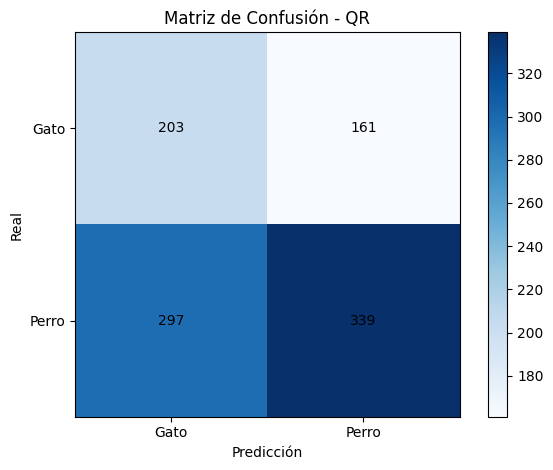

In [ ]:
def plot_confusion_matrix(cm, title):
    fig, ax = plt.subplots()
    im = ax.imshow(cm, cmap="Blues")

    ax.set_xticks([0, 1])
    ax.set_yticks([0, 1])
    ax.set_xticklabels(["Gato", "Perro"])
    ax.set_yticklabels(["Gato", "Perro"])
    ax.set_xlabel("Predicción")
    ax.set_ylabel("Real")
    ax.set_title(title)

    # valores dentro de cada celda
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(j, i, int(cm[i, j]),
                    ha="center", va="center")

    fig.colorbar(im, ax=ax)
    plt.tight_layout()
    plt.show()
    
plot_confusion_matrix(matrizConfusion_Cholesky, "Matriz de Confusión - Cholesky")
plot_confusion_matrix(matrizConfusion_QR, "Matriz de Confusión - QR")
plot_confusion_matrix(matrizConfusion_SVD, "Matriz de Confusión - SVD")